CLASSICAL GENERATIVE ADVERSARIAL NETWORK

Training Classical GAN...

--- Classical Testing Phase ---


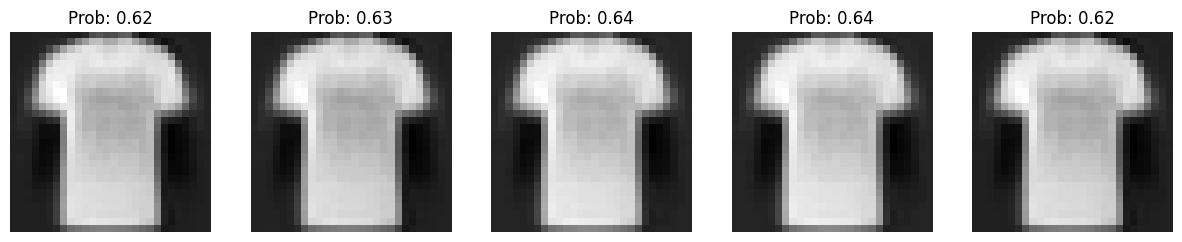

Classical Parameter Count: 10699
Average Prob Real: 0.6303


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
(x_train, y_train), _ = fashion_mnist.load_data()
X_raw = x_train[y_train == 0][:1000].reshape(-1, 784) / 255.0 # T-shirts
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_raw)
X_pca_tensor = torch.tensor(X_pca, dtype=torch.float32).to(device)

# --- Models ---
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(10, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 10), nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Linear(10, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.main(x)

# --- Training ---
gen, disc = Generator().to(device), Discriminator().to(device)
opt_g, opt_d = optim.Adam(gen.parameters(), lr=0.001), optim.Adam(disc.parameters(), lr=0.001)
criterion = nn.BCELoss()

print("Training Classical GAN...")
for epoch in range(100):
    idx = torch.randint(0, len(X_pca_tensor), (16,))
    real = X_pca_tensor[idx]
    noise = torch.randn(16, 10).to(device)
    fake = gen(noise)

    # Train D
    loss_d = criterion(disc(real), torch.full((16, 1), 0.9).to(device)) + \
             criterion(disc(fake.detach()), torch.full((16, 1), 0.1).to(device))
    opt_d.zero_grad(); loss_d.backward(); opt_d.step()

    # Train G
    loss_g = criterion(disc(fake), torch.ones(16, 1).to(device))
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()

# --- Testing Phase (WITH METRIC TRACKING) ---
print("\n--- Classical Testing Phase ---")
img_c_samples = [] # List for SSIM comparison
c_probs = []       # List for self-calculating Avg Prob

with torch.no_grad():
    test_noise = torch.randn(5, 10).to(device)
    test_fakes = gen(test_noise)
    verdicts = disc(test_fakes)

    plt.figure(figsize=(15, 4))
    for i in range(5):
        # Extracts Probability Verdict
        prob = verdicts[i].item()
        c_probs.append(prob)

        # Invert PCA to 28x28 image
        img = pca.inverse_transform(test_fakes[i].cpu().numpy().reshape(1, -1)).reshape(28, 28)
        img_c_samples.append(img)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Prob: {prob:.2f}")
        plt.axis('off')
    plt.show()

# --- Parameter Calculations ---
# Dynamically count trainable parameters for the final table
total_c_params = sum(p.numel() for p in gen.parameters() if p.requires_grad) + \
                 sum(p.numel() for p in disc.parameters() if p.requires_grad)

print(f"Classical Parameter Count: {total_c_params}")
print(f"Average Prob Real: {np.mean(c_probs):.4f}")

Hybrid QUANTUM Classical GENERATIVE ADVERSAREAL NETWORK -Quantum Counterpart

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 119.4 MB/s eta 0:00:00


Training Quantum GAN...
Epoch 0 | Loss D: 1.3887 | Loss G: 0.6855
Epoch 5 | Loss D: 1.3814 | Loss G: 0.6939
Epoch 10 | Loss D: 1.3851 | Loss G: 0.7014
Epoch 15 | Loss D: 1.3834 | Loss G: 0.6959
Epoch 20 | Loss D: 1.3816 | Loss G: 0.6959
Epoch 25 | Loss D: 1.3762 | Loss G: 0.6999

--- Quantum Testing Phase (no_grad) ---


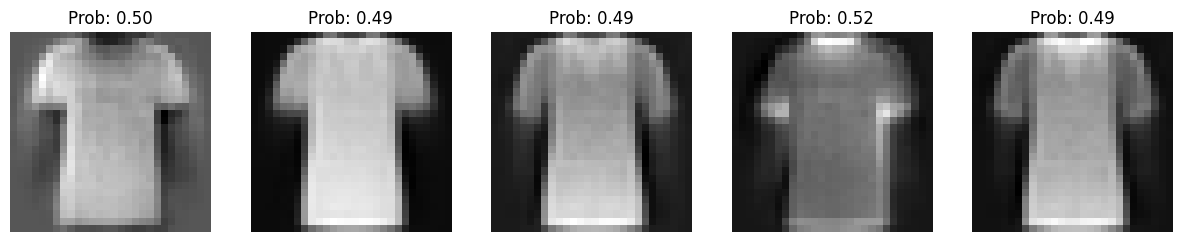

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# --- Data Prep ---
(x_train, y_train), _ = fashion_mnist.load_data()
# Filter for T-shirts (label 0)
X_raw = x_train[y_train == 0][:1000].reshape(-1, 784) / 255.0
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_raw)
X_pca_norm = (X_pca - X_pca.min()) / (X_pca.max() - X_pca.min()) * 2 - 1
X_pca_tensor = torch.tensor(X_pca_norm, dtype=torch.float32)

# --- Quantum Circuit ---
dev = qml.device("lightning.qubit", wires=10)
@qml.qnode(dev, interface="torch", diff_method="adjoint")
def q_circuit(noise, weights):
    for i in range(10): qml.RY(noise[i], wires=i)
    for l in range(2):
        for i in range(10): qml.RZ(weights[l, i], wires=i)
        for i in range(10): qml.CNOT(wires=[i, (i + 1) % 10])
    return [qml.expval(qml.PauliZ(i)) for i in range(10)]

# --- Training ---
q_weights = torch.randn(2, 10, requires_grad=True)
q_disc = nn.Sequential(nn.Linear(10, 32), nn.LeakyReLU(0.2), nn.Linear(32, 1), nn.Sigmoid())
opt_g, opt_d = optim.Adam([q_weights], lr=0.01), optim.Adam(q_disc.parameters(), lr=0.002)

print("Training Quantum GAN...")
for epoch in range(30):
    # Using torch.randint for tensor indexing
    idx = torch.randint(0, len(X_pca_tensor), (16,))
    real = X_pca_tensor[idx]
    noise = torch.randn(16, 10)
    fake = torch.stack([torch.stack(q_circuit(n, q_weights)) for n in noise]).float()

    loss_d = nn.BCELoss()(q_disc(real), torch.full((16, 1), 0.9)) + \
             nn.BCELoss()(q_disc(fake.detach()), torch.full((16, 1), 0.1))
    opt_d.zero_grad(); loss_d.backward(); opt_d.step()

    loss_g = nn.BCELoss()(q_disc(fake), torch.ones(16, 1))
    opt_g.zero_grad(); loss_g.backward(); opt_g.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Loss D: {loss_d.item():.4f} | Loss G: {loss_g.item():.4f}")

# --- Quantum Testing Phase ---
print("\n--- Quantum Testing Phase (no_grad) ---")
img_q_samples = []
q_probs = []

with torch.no_grad():
    test_noise = torch.randn(5, 10)
    test_fakes = torch.stack([torch.stack(q_circuit(n, q_weights)) for n in test_noise]).float()
    verdicts = q_disc(test_fakes)

    plt.figure(figsize=(15, 4))
    for i in range(5):
        prob = verdicts[i].item()
        q_probs.append(prob)

        f = test_fakes[i].numpy()
        unnorm = (f + 1) / 2 * (X_pca.max() - X_pca.min()) + X_pca.min()
        img = pca.inverse_transform(unnorm.reshape(1, -1)).reshape(28, 28)
        img_q_samples.append(img)

        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Prob: {prob:.2f}")
        plt.axis('off')
    plt.show()

# Calculating dynamic stats
avg_q_prob = np.mean(q_probs)
#  Quantum parameter Calculations (Generator weights + Discriminator weights)
q_gen_params = q_weights.numel()
q_disc_params = sum(p.numel() for p in q_disc.parameters() if p.requires_grad)
total_q_params = q_gen_params + q_disc_params

Comparative Study

In [ ]:
from skimage.metrics import structural_similarity as ssim
import pandas as pd
import numpy as np

# Preparing Real Images
img_real = X_raw[:5].reshape(-1, 28, 28)

# Dynamic Parameter Calculation for Classical Model
c_gen_params = sum(p.numel() for p in gen.parameters() if p.requires_grad)
c_disc_params = sum(p.numel() for p in disc.parameters() if p.requires_grad)
total_c_params = c_gen_params + c_disc_params

def calculate_average_ssim(real_images, generated_images):
    scores = []
    for r, g in zip(real_images, generated_images):
        r_n = (r - r.min()) / (r.max() - r.min())
        g_n = (g - g.min()) / (g.max() - g.min())
        scores.append(ssim(r_n, g_n, data_range=1.0))
    return np.mean(scores)

#  Calculating metrics
ssim_c = calculate_average_ssim(img_real, img_c_samples)
ssim_q = calculate_average_ssim(img_real, img_q_samples)
avg_c_prob = np.mean(c_probs) if 'c_probs' in locals() else 0.0

# Comparison Table
results = {
    "Metric": ["Total Trainable Params", "Avg Prob Verdict", "Average SSIM"],
    "Classical GAN": [f"{total_c_params:,}", f"{avg_c_prob:.4f}", f"{ssim_c:.4f}"],
    "Quantum GAN": [f"{total_q_params:,}", f"{avg_q_prob:.4f}", f"{ssim_q:.4f}"]
}

print("\n--- FINAL RESEARCH COMPARISON TABLE ---")
print(pd.DataFrame(results).to_string(index=False))



# 1. Calculating Parameter Efficiency Ratio (How many classical parameters are replaced by a single quantum parameter?)
param_ratio = total_c_params / total_q_params

# 2. Calculating Structural Fidelity Percentage (How close is the Quantum model to the Classical baseline in quality?)
fidelity_pct = (ssim_q / ssim_c) * 100

# 3. Calculating Parameter Utilization ( What percentage of the classical "brain power" did the Quantum model use?)
utilization_pct = ( total_q_params /  total_c_params) * 100

print(f"--- QUANTUM ADVANTAGE ANALYSIS ---")
print(f"Parameter Efficiency Ratio: {param_ratio:.2f}x")
print(f"Structural Fidelity: {fidelity_pct:.2f}% of Classical Baseline")
print(f"Resource Utilization: {utilization_pct:.2f}% of Classical Parameters")

print(f"\nConclusion: The Quantum GAN achieved {fidelity_pct:.1f}% fidelity ")
print(f"using only {utilization_pct:.1f}% of the classical parameter budget.")


--- FINAL RESEARCH COMPARISON TABLE ---
                Metric Classical GAN Quantum GAN
Total Trainable Params        10,699         405
      Avg Prob Verdict        0.6303      0.4988
          Average SSIM        0.4041      0.3420
--- QUANTUM ADVANTAGE ANALYSIS ---
Parameter Efficiency Ratio: 26.42x
Structural Fidelity: 84.64% of Classical Baseline
Resource Utilization: 3.79% of Classical Parameters

Conclusion: The Quantum GAN achieved 84.6% fidelity 
using only 3.8% of the classical parameter budget.


Model Saving


In [ ]:


# Save Classical Models
torch.save(gen.state_dict(), 'classical_generator.pth')
torch.save(disc.state_dict(), 'classical_discriminator.pth')

# Save Quantum Generator Weights (The 20 parameters)
torch.save(q_weights, 'quantum_weights.pth')

# Save Quantum Discriminator
torch.save(q_disc.state_dict(), 'quantum_discriminator.pth')

Results and Graphs

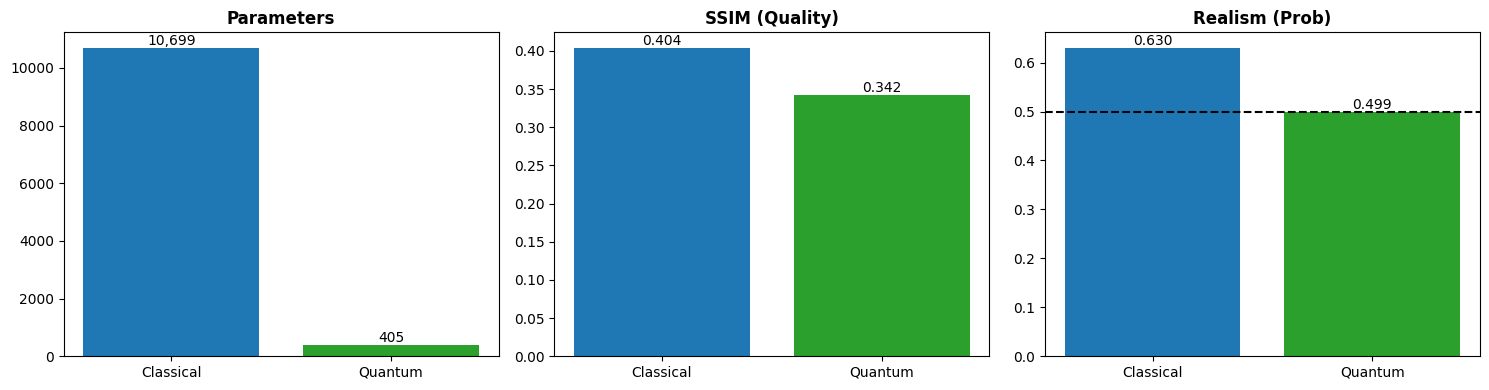

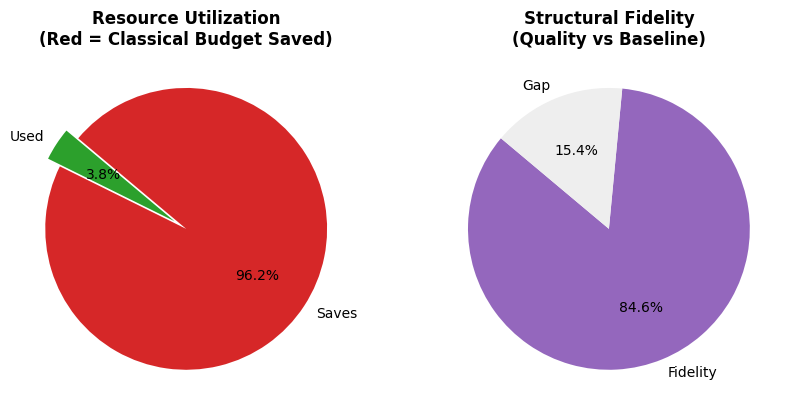

<Figure size 640x480 with 0 Axes>

In [1]:
import matplotlib.pyplot as plt

results = {
    'Parameters': [10699, 405],
    'SSIM (Quality)': [0.4041, 0.3420],
    'Realism (Prob)': [0.6303, 0.4988]
}
labels = ['Classical', 'Quantum']

# Comparison Bar Charts
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, values) in enumerate(results.items()):
    ax[i].bar(labels, values, color=['#1f77b4', '#2ca02c'])
    ax[i].set_title(name, fontweight='bold')
    if 'Prob' in name: ax[i].axhline(0.5, color='black', linestyle='--', label='Ideal')
    for j, v in enumerate(values):
        ax[i].text(j, v, f"{v:,}" if i==0 else f"{v:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Advantage Pie Charts (Red for Savings)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Resource Usage: Red highlights the massive 96.2% savings
ax1.pie([3.8, 96.2], labels=['Used', 'Saves'], autopct='%1.1f%%',
        colors=['#2ca02c', '#d62728'], startangle=140, explode=(0.1, 0))
ax1.set_title("Resource Utilization\n(Red = Classical Budget Saved)", fontweight='bold')

# Structural Fidelity: 84.6% of original quality kept
ax2.pie([84.6, 15.4], labels=['Fidelity', 'Gap'], autopct='%1.1f%%',
        colors=['#9467bd', '#eeeeee'], startangle=140)
ax2.set_title("Structural Fidelity\n(Quality vs Baseline)", fontweight='bold')

plt.show()
plt.savefig('quantum_advantage_analysis.png')